# Peramalan kadar NO₂ di daerah Sampang Madura

## Latar Belakang

Peningkatan aktivitas industri, transportasi, dan kegiatan ekonomi di wilayah Sampang, Madura,
telah menyebabkan peningkatan kadar polutan udara, khususnya Nitrogen Dioksida (NO₂). Gas ini merupakan
hasil sampingan dari pembakaran bahan bakar fosil pada kendaraan bermotor, pembangkit listrik,
dan proses industri lokal.

Kadar NO₂ yang tinggi dapat menimbulkan dampak kesehatan serius bagi masyarakat,
seperti gangguan pernapasan, iritasi paru-paru, serta memperburuk kondisi asma dan bronkitis.
Selain itu, NO₂ berkontribusi terhadap penurunan kualitas lingkungan, termasuk pembentukan
hujan asam dan degradasi udara.

Pemantauan dan peramalan kadar NO₂ harian menggunakan dataset dari satelit Sentinel-5P
menjadi penting untuk mendukung kebijakan lingkungan, mitigasi risiko kesehatan,
serta perencanaan transportasi dan industri berkelanjutan di wilayah Sampang.


## 1. Pengumpulan Data
Pertama kita akan mengumpulkan data Time Series Harian kadar NO2 di daerah Sampang. Pengumpulan data dari sumber website https://dataspace.copernicus.eu/, buat akun terlebih dahulu di website copernicus tersebut.

Dokumentasi cara pengambilan data di https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html

In [64]:
pip install openeo

In [ ]:
import openeo

In [ ]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=MUAA-XYJQ 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Code diatas memerlukan titik koordinasi area yang akan diambil datanya. Berikut adalah koordinat daerah Sampang yang digunakan: https://geojson.io/?map=10.81/-7.18/113.23

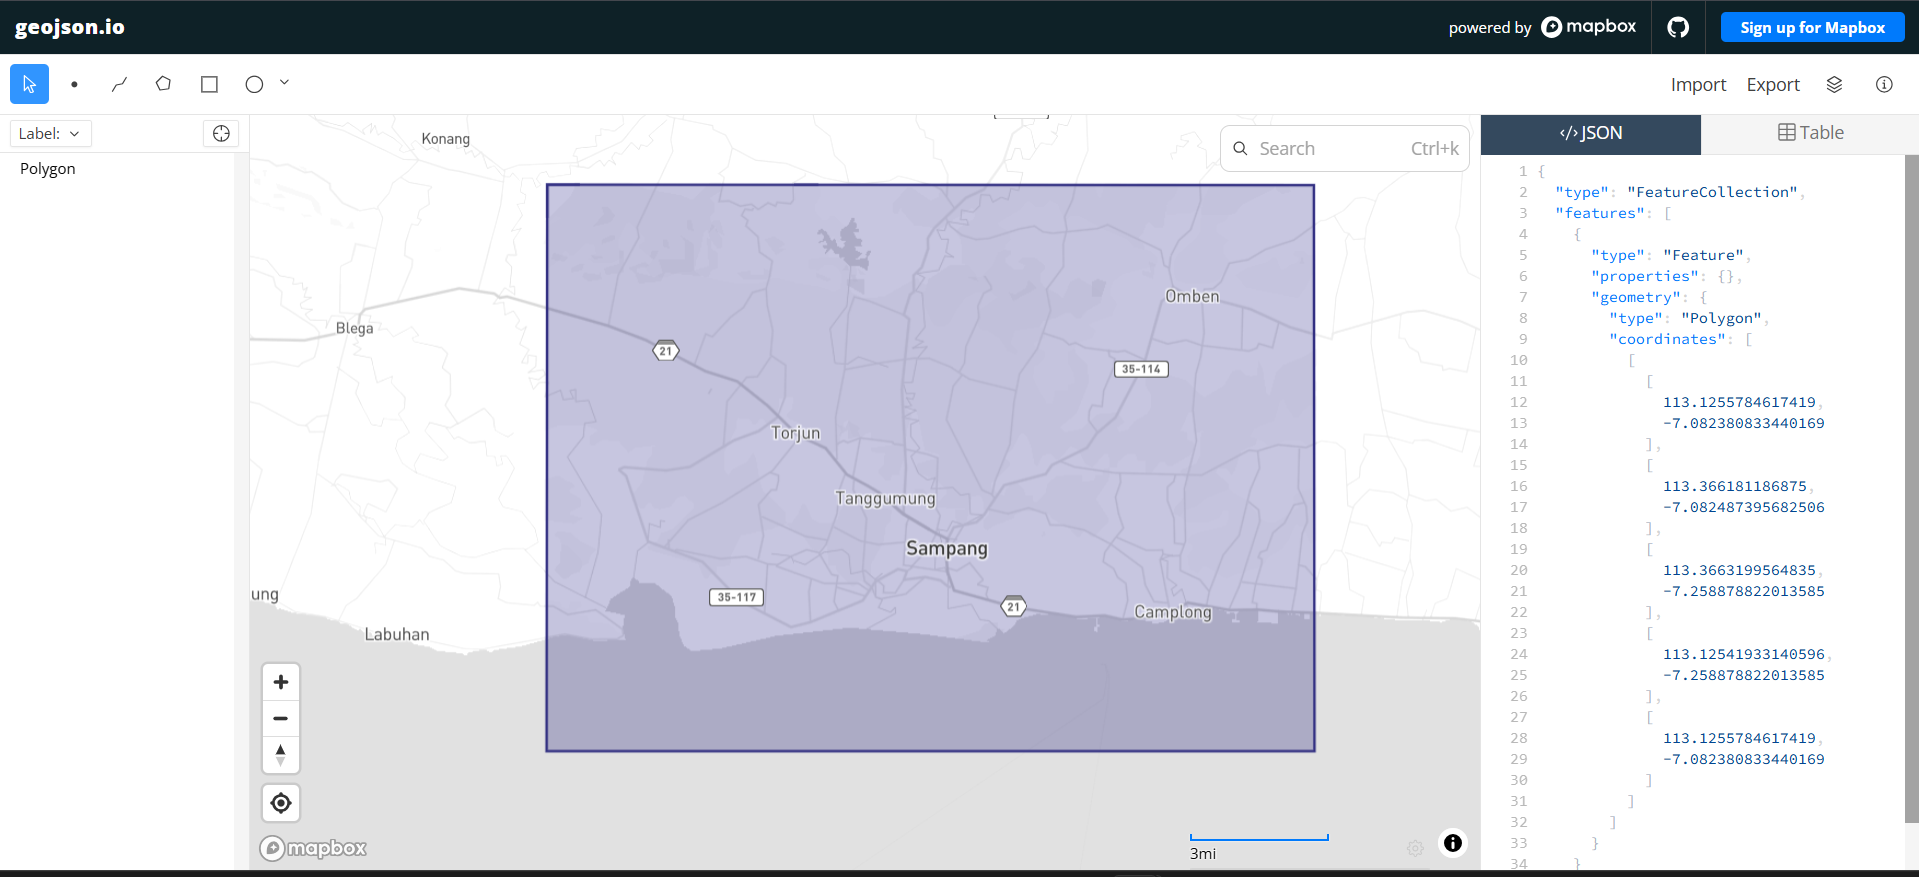

In [ ]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [113.1255784617419, -7.082380833440169],
            [113.366181186875, -7.082487395682506],
            [113.3663199564835, -7.258878822013585],
            [113.12541933140596, -7.258878822013585],
            [113.1255784617419, -7.082380833440169]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-05-01", "2026-06-01"],
    spatial_extent = {
    "west": 113.1255784617419,
    "south": -7.258878822013585,
    "east": 113.3663199564835,
    "north": -7.082380833440169
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

Jalankan batch job untuk mengambil data NO2 di daerah Sampang:

In [ ]:
job = s5post.execute_batch(title="NO2_Sampang", outputfile="NO2_Sampang.nc")

0:00:00 Job 'j-260603050046447b962f5de78e301197': send 'start'
0:00:10 Job 'j-260603050046447b962f5de78e301197': queued (progress 0%)
0:00:16 Job 'j-260603050046447b962f5de78e301197': queued (progress 0%)
0:00:22 Job 'j-260603050046447b962f5de78e301197': queued (progress 0%)
0:00:30 Job 'j-260603050046447b962f5de78e301197': running (progress N/A)
0:00:40 Job 'j-260603050046447b962f5de78e301197': running (progress N/A)
0:00:53 Job 'j-260603050046447b962f5de78e301197': running (progress N/A)
0:01:08 Job 'j-260603050046447b962f5de78e301197': running (progress N/A)
0:01:28 Job 'j-260603050046447b962f5de78e301197': running (progress N/A)
0:01:52 Job 'j-260603050046447b962f5de78e301197': running (progress N/A)
0:02:22 Job 'j-260603050046447b962f5de78e301197': running (progress N/A)
0:02:59 Job 'j-260603050046447b962f5de78e301197': running (progress N/A)
0:03:46 Job 'j-260603050046447b962f5de78e301197': running (progress N/A)
0:04:45 Job 'j-260603050046447b962f5de78e301197': running (progress

Ketika proses pengambilan data, aktivitas kalian akan terekam di halaman https://openeo.dataspace.copernicus.eu/?discover=0 Disitu terdapat nama dataset dan status pengambilan data.

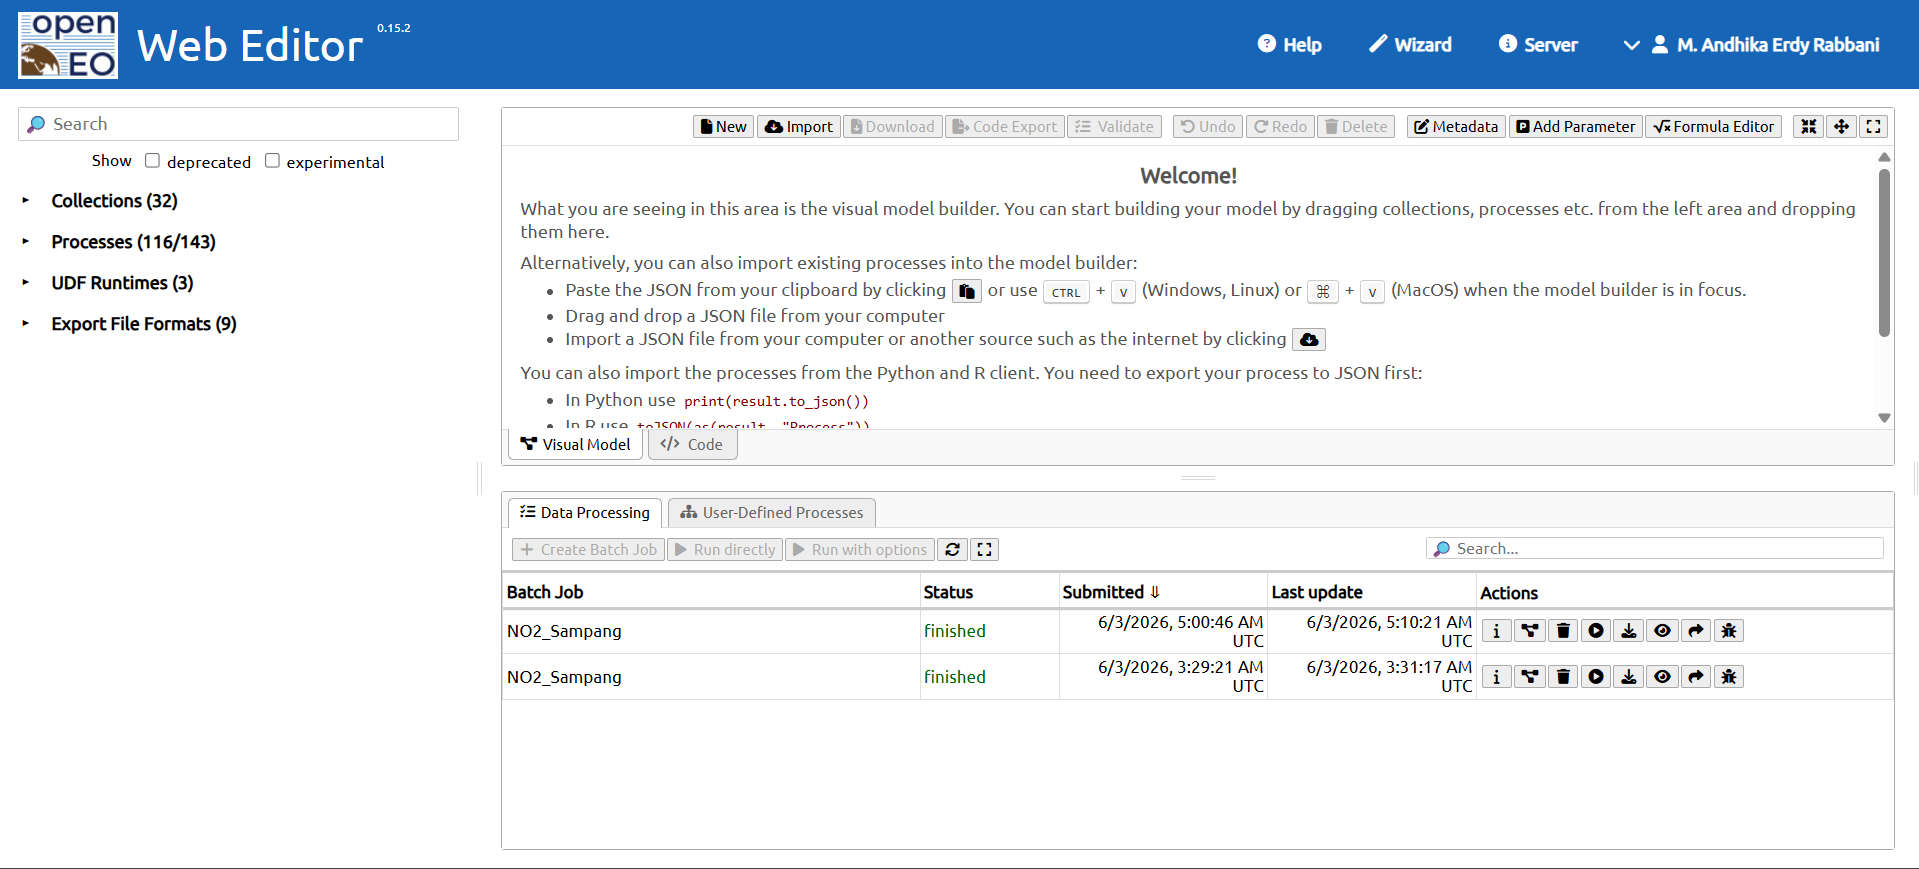

## 2. Preprocessing Data

Setelah kita mengambil data, data bisa diunduh di halaman https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2. File akan berbentuk .nc. Kita cuman perlu kolom date dan NO2.

In [ ]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.6 MB/s eta 0:00:00


In [ ]:
import netCDF4

file_path = "NO2_Sampang.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())
# dict_keys(['t', 'x', 'y', 'crs', 'NO2'])

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
# type <class 'numpy.ma.core.MaskedArray'>

print(len(no2))
# banyaknya data record NO2 725

print(len(no2[0]))
# panjang data perbaris 9

print(len(no2[0][0]))
# panjang perdata 8

print(no2[0][0][0])
# 3.7701793e-05

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
1119
6
5
--


Dari code diatas kita mengetahui bentuk data dari kolom NO2 nya.

Untuk melihat 10 data pertama adalah:

In [ ]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[-- -- -- -- --]
 [-- -- -- -- --]
 [-- -- -- -- --]
 [-- -- -- -- --]
 [-- -- -- -- --]
 [-- -- -- -- --]]
[[-- -- -- -- --]
 [-- -- -- -- --]
 [-- -- -- -- --]
 [-- -- -- -- --]
 [-- -- -- -- --]
 [-- -- -- -- --]]
[[-- -- -- -- 1.840660479501821e-05]
 [-- -- -- -- 3.389916309970431e-05]
 [-- -- -- -- 3.389916309970431e-05]
 [-- -- -- -- 9.263978313356347e-07]
 [-- -- -- -- 3.0679526389576495e-05]
 [-- -- -- -- 3.0679526389576495e-05]]
[[-- -- -- -- --]
 [-- -- 3.0006847737240605e-05 1.9346856788615696e-05
  4.2194642446702346e-05]
 [1.5271514712367207e-05 1.3194524399295915e-05 3.0006847737240605e-05
  1.9346856788615696e-05 2.0079683963558637e-05]
 [1.5271514712367207e-05 2.116582436428871e-05 2.044068241957575e-05
  -2.562670431416336e-07 2.14827450690791e-05]
 [9.792706805455964e-06 2.116582436428871e-05 1.2526478712970857e-05
  1.0462073078087997e-05 3.116003790637478e-05]
 [2.168401078961324e-05 2.2513237126986496e-05 1.2526478712970857e-05
  2.12155955523

### a. Mengatasi Missing Value menggunakan metode Interpolasi Linear

In [ ]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)
# Untuk jaga-jaga jika terdapat '--' tidak berubah menjadi 0
no2_filled = no2_filled.filled(0)

# loop tiap grid (y,x)
for i in range(no2.shape[1]):     # 9 baris
    for j in range(no2.shape[2]): # 8 kolom
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(method='linear', limit_direction='both').to_numpy()

Dengan code diatas, missing value yang terdapat pada data NO2 akan diisi secara otomatis menggunakan metode Interpolasi Linear.

### b. Rata-rata kan Data dan ubah Datetime

Setelah mengatasi missing value, data NO₂ harian di wilayah Sampang, Madura akan dirata-rata sehingga setiap hari memiliki satu nilai rata-rata NO₂. Selama proses ini, kolom tanggal (date) juga diambil dan disimpan dalam array terpisah.

Datetime awalnya yang lengkap dengan jam, menit, dan detik (misal 2023-05-01 00:00:00) akan diubah menjadi format tanggal saja (2023-05-01) karena analisis ini hanya menggunakan data harian, sehingga jam dan menit tidak diperlukan.

Langkah ini memastikan dataset time series harian NO₂ siap untuk normalisasi, transformasi supervised, dan prediksi KNN Regression.

In [ ]:
new_dates = []
new_no2 = []
for i in range(len(dates)):
    # ubah format datetime
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    new_no2.append(np.mean(no2_filled[i]))

### c. Simpan data dalam bentuk CSV

Setelah itu kita akan membentuk data menjadi DataFrame Pandas untuk disimpan menjadi CSV.

In [ ]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_Sampang.csv", index=False)

Untuk mengatasi missing value dan menyimpan data ke CSV sudah berhasil.

### d. Pengecekan Missing Value data harian pada CSV
Sekarang setelah data berbentuk CSV, kita cek apakah data Time Series harian lengkap. Cara men-cek apakah data Time Series Harian lengkap gunakan code dibawah:

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Sampang.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-05-01"
end_date = "2026-05-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 8
Daftar tanggal missing:
DatetimeIndex(['2023-11-11', '2024-01-01', '2024-03-11', '2024-03-23',
               '2024-08-12', '2025-01-30', '2025-01-31', '2026-02-24'],
              dtype='datetime64[ns]', freq=None)


Dalam kasus saya ini, terdapat 8 hari missing value. Kita akan mengatasi lagi missing value menggunakan metode Interpolasi Linear. Cara memperbaikinya gunakan code dibawah:

In [35]:
import pandas as pd

# 4️⃣ Pastikan kolom date sebagai datetime dan urutkan
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 5️⃣ Buat rentang tanggal lengkap sesuai data
full_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')

# 6️⃣ Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# 7️⃣ Interpolasi linear dan isi NaN di awal/akhir
df['NO2'] = df['NO2'].interpolate(method='time').bfill().ffill()

# 8️⃣ Reset index dan simpan CSV
df = df.reset_index()
df.to_csv("/content/no2_timeseries_interpolated.csv", index=False)

# 9️⃣ Cek hasil
print(df.head())
print(df.info())

        date       NO2
0 2023-05-01  0.000018
1 2023-05-02  0.000018
2 2023-05-03  0.000018
3 2023-05-04  0.000018
4 2023-05-05  0.000012
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1127 entries, 0 to 1126
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1127 non-null   datetime64[ns]
 1   NO2     1127 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 17.7 KB
None


Setelah saya cek missing value harian, sudah tidak ada lagi missing value.

In [36]:
import pandas as pd

# Baca CSV hasil preprocessing/interpolasi
df = pd.read_csv("no2_timeseries_interpolated.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = df['date'].min()
end_date = df['date'].max()
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

# Tampilkan
print("Setelah saya cek missing value harian, sudah tidak ada lagi missing value.\n")
print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Setelah saya cek missing value harian, sudah tidak ada lagi missing value.

Jumlah hari missing: 0
Daftar tanggal missing:
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


### e. Deteksi Outlier IQR
Setelah kita mengisi missing value menggunakan metode Interpolasi Linear, selanjutnya kita akan mendeteksi Outlier menggunakan metode IQR.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("no2_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())


Jumlah Outlier (IQR): 11
          date       NO2
426 2024-06-30  0.000059
427 2024-07-01  0.000049
428 2024-07-02  0.000039
606 2024-12-27  0.000037
780 2025-06-19  0.000036


Untuk men-visualisasi outlier:

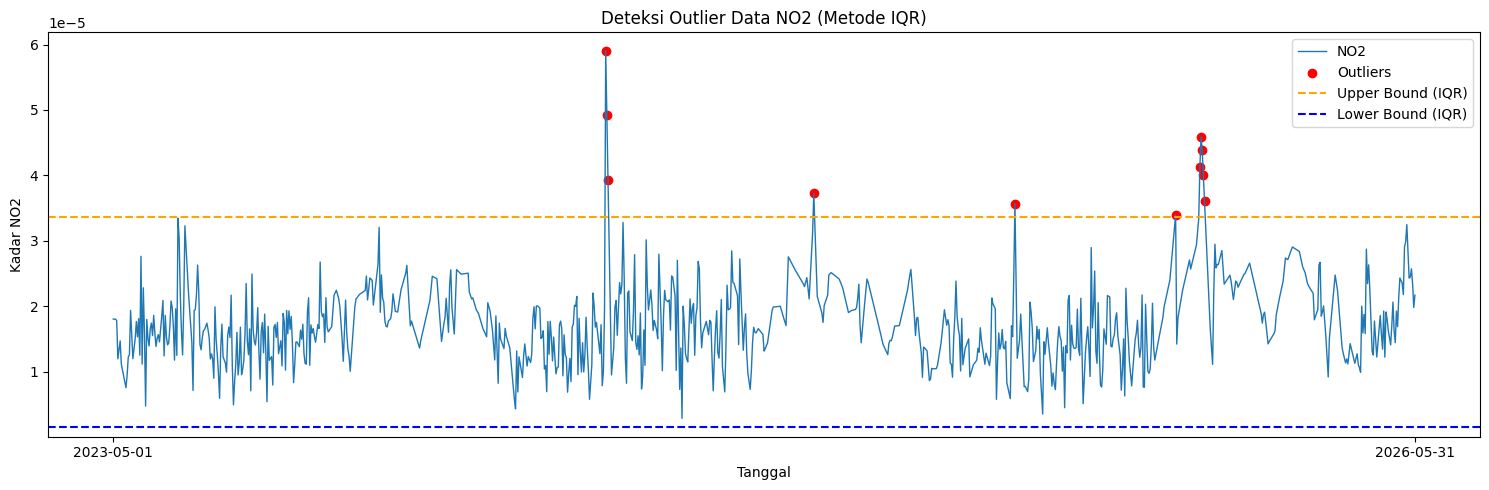

In [38]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

# Garis batas atas & bawah
plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue', linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Setelah itu, kita akan menghapus data outlier. Karena data ini merupakan data Time Series, maka data outlier yang dihapus akan diisi kembali menggunakan Interpolasi Linear.

In [39]:
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

print("Jumlah nilai yang dinyatakan sebagai outlier:", df['NO2_cleaned'].isna().sum())

# Interpolasi linear untuk mengisi kembali nilai outlier
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')

# Jika masih tersisa NaN di ujung data, isi dengan forward/backward fill
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()
# df['NO2_filled'] = df['NO2_filled'].fillna(method='bfill').fillna(method='ffill')

print("Jumlah missing setelah interpolasi:", df['NO2_filled'].isna().sum())

Jumlah nilai yang dinyatakan sebagai outlier: 11
Jumlah missing setelah interpolasi: 0


Visualisasi data setelah menghapus Outlier dan mengisi kembali menggunakan Interpolasi Linear:

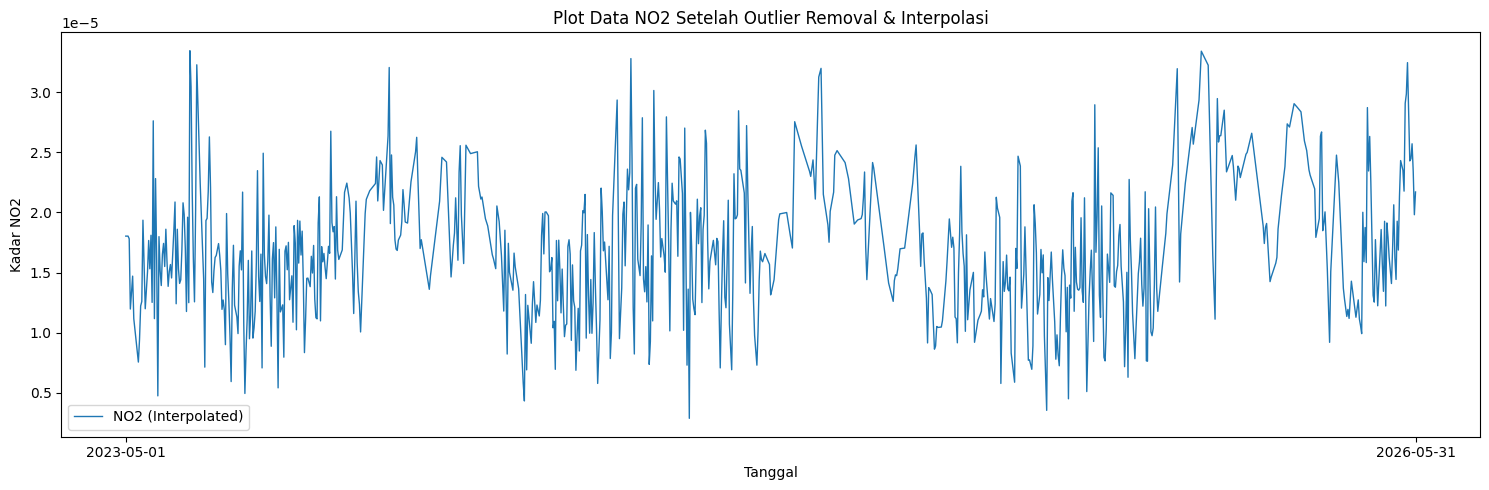

In [40]:
plt.figure(figsize=(15,5))
# Plot data hasil interpolasi
plt.plot(df['date'], df['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)
# Tampilkan hanya tanggal awal dan akhir di sumbu X
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.title("Plot Data NO2 Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Modeling menggunakan KNN Regression

Dengan data time series kadar NO₂ harian di wilayah Sampang, kita akan memprediksi kadar NO₂ untuk satu hari berikutnya. Data diubah menjadi format supervised dengan membuat fitur dari beberapa hari sebelumnya (misal 1–4 hari) sebagai input, dan nilai NO₂ hari ini sebagai label.

Selanjutnya, kita akan menghitung korelasi antara nilai hari sebelumnya dengan nilai hari ini untuk melihat seberapa kuat hubungan setiap lag. Dengan cara ini, kita bisa menentukan jumlah lag terbaik yang digunakan sebagai fitur. Selain itu, kita juga akan membandingkan performa model saat menggunakan jumlah hari sebelumnya yang berbeda (misal 4, 10, atau 30 hari) untuk melihat apakah menambah jumlah hari sebelumnya dapat meningkatkan akurasi prediksi NO₂ harian.

Langkah ini penting agar model KNN Regression dapat memanfaatkan informasi historis secara optimal tanpa overfitting, sehingga prediksi lebih akurat untuk perencanaan kualitas udara di wilayah Sampang.

### a. Uji Korelasi Data
Sebelum masuk ke tahap modeling, data NO₂ harian merupakan data time series tanpa label sehingga bersifat unsupervised. Untuk mempersiapkannya agar bisa digunakan pada model prediksi, data ini diubah menjadi supervised dataset.

Caranya adalah dengan menjadikan nilai NO₂ hari sebelumnya sebagai fitur dan nilai NO₂ hari ini sebagai label (t). Misalnya, jika menggunakan lag 30, fitur terdiri dari 30 hari sebelumnya (t-30, t-29, …, t-1) dan label adalah hari saat ini (t).

In [43]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1️⃣ Pastikan df sudah ada kolom NO2
df = pd.read_csv("no2_timeseries_interpolated.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2️⃣ Normalisasi NO2 menjadi 0-1
scaler = MinMaxScaler()
df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

# 3️⃣ Sekarang baru bisa buat dataset supervised
def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)
    df_supervised['NO2(t)'] = data
    df_supervised.dropna(inplace=True)
    return df_supervised

# Contoh penggunaan
supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

# Ambil semua lag dan kolom target
lag_cols = supervised_df30.drop(columns="NO2(t)").columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

print(correlations)

NO2(t-30)    0.205416
NO2(t-29)    0.218698
NO2(t-28)    0.229138
NO2(t-27)    0.256749
NO2(t-26)    0.228596
NO2(t-25)    0.241281
NO2(t-24)    0.231659
NO2(t-23)    0.228388
NO2(t-22)    0.234058
NO2(t-21)    0.234986
NO2(t-20)    0.230313
NO2(t-19)    0.246352
NO2(t-18)    0.224100
NO2(t-17)    0.235801
NO2(t-16)    0.267800
NO2(t-15)    0.262604
NO2(t-14)    0.278221
NO2(t-13)    0.288758
NO2(t-12)    0.310167
NO2(t-11)    0.345362
NO2(t-10)    0.326749
NO2(t-9)     0.327031
NO2(t-8)     0.344108
NO2(t-7)     0.335239
NO2(t-6)     0.370330
NO2(t-5)     0.408748
NO2(t-4)     0.410393
NO2(t-3)     0.488489
NO2(t-2)     0.587528
NO2(t-1)     0.743812
dtype: float64


Nilai korelasi antar fitur dan label memiliki skala dari -1 hingga 1, di mana nilai mendekati 1 menunjukkan hubungan positif yang kuat, nilai mendekati -1 menunjukkan hubungan negatif yang kuat, dan nilai mendekati 0 menunjukkan hubungan lemah atau tidak ada hubungan.

Dari analisis korelasi terhadap label hari ini (t), fitur dengan korelasi tertinggi dipilih sebagai input untuk model. Pada kasus data Sampang, fitur t-1 hingga t-4 memiliki korelasi lebih dari 0.5, sehingga dianggap cukup informatif untuk digunakan sebagai lag input pada model KNN Regression.

### b. Normalisasi Data
karena kita menggunakan model KNN Regression, maka perlu normalisasi data menggunakan min-max Scaler.

In [44]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

Maka data akan di-normalisasi 0-1.

In [45]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Baca CSV hasil preprocessing (interpolasi + outlier removed)
df = pd.read_csv("no2_timeseries_interpolated.csv")

# Pastikan kolom date sebagai datetime
df['date'] = pd.to_datetime(df['date'])

# Normalisasi NO2 ke 0-1
scaler = MinMaxScaler()
df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

# Tampilkan 5 baris pertama
print(df.head())

# Tampilkan info DataFrame
print(df.info())

        date       NO2  NO2_scaled
0 2023-05-01  0.000018    0.269907
1 2023-05-02  0.000018    0.269907
2 2023-05-03  0.000018    0.269907
3 2023-05-04  0.000018    0.265987
4 2023-05-05  0.000012    0.161904
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1127 entries, 0 to 1126
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1127 non-null   datetime64[ns]
 1   NO2         1127 non-null   float64       
 2   NO2_scaled  1127 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 26.5 KB
None


### c. Mengubah Data
Sekarang data NO₂ diubah dari format awal menjadi supervised dataset untuk keperluan prediksi. Awalnya, mungkin hanya menggunakan 2 fitur lag, namun berdasarkan hasil uji korelasi, fitur yang paling informatif adalah t-1 sampai t-4. Oleh karena itu, dataset dibuat dengan 4 hari sebelumnya sebagai fitur dan hari saat ini (t) sebagai label, sehingga total terdapat 5 kolom:

NO2(t-4)
NO2(t-3)
NO2(t-2)
NO2(t-1)
NO2(t) (label)

Selain itu, dibuat juga dataset dengan 10 hari sebelumnya sebagai fitur untuk membandingkan performa model dan melihat apakah menambah jumlah lag historis dapat meningkatkan akurasi prediksi.

In [46]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

      NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4     0.269907  0.269907  0.269907  0.265987  0.161904
5     0.269907  0.269907  0.265987  0.161904  0.186274
6     0.269907  0.265987  0.161904  0.186274  0.210645
7     0.265987  0.161904  0.186274  0.210645  0.147664
8     0.161904  0.186274  0.210645  0.147664  0.131583
...        ...       ...       ...       ...       ...
1122  0.480439  0.526879  0.454092  0.381306  0.384534
1123  0.526879  0.454092  0.381306  0.384534  0.406686
1124  0.454092  0.381306  0.384534  0.406686  0.365766
1125  0.381306  0.384534  0.406686  0.365766  0.301584
1126  0.384534  0.406686  0.365766  0.301584  0.335312

[1123 rows x 5 columns]
(1123, 5)


Untuk membuat data 10 hari sebelum tinggal tambah code dibawah (ubah parameter n_lag).

In [47]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

      NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10     0.269907  0.269907  0.269907  0.265987  0.161904  0.186274  0.210645   
11     0.269907  0.269907  0.265987  0.161904  0.186274  0.210645  0.147664   
12     0.269907  0.265987  0.161904  0.186274  0.210645  0.147664  0.131583   
13     0.265987  0.161904  0.186274  0.210645  0.147664  0.131583  0.115502   
14     0.161904  0.186274  0.210645  0.147664  0.131583  0.115502  0.099422   
...         ...       ...       ...       ...       ...       ...       ...   
1122   0.328894  0.381833  0.374733  0.367633  0.336553  0.466703  0.480439   
1123   0.381833  0.374733  0.367633  0.336553  0.466703  0.480439  0.526879   
1124   0.374733  0.367633  0.336553  0.466703  0.480439  0.526879  0.454092   
1125   0.367633  0.336553  0.466703  0.480439  0.526879  0.454092  0.381306   
1126   0.336553  0.466703  0.480439  0.526879  0.454092  0.381306  0.384534   

      NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10  

### d. Modeling dan Evaluation
Sekarang dari 2 data yang sudah kita rubah, kita train menggunakan model KNN Regression.

In [48]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Hindari pembagian dengan nol
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur & label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} — Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred


# Train model untuk 4 hari sebelumnya
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")

# Train model untuk 10 hari sebelumnya
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size: 898 — Test Size: 225
RMSE: 0.075471
R² Score: 0.5373
MAPE: 15.1253%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 893 — Test Size: 224
RMSE: 0.075882
R² Score: 0.5299
MAPE: 17.1465%


Berdasarkan hasil evaluasi akurasi model KNN Regression sebelumnya, terlihat bahwa penggunaan lebih banyak hari sebelumnya sebagai fitur cenderung meningkatkan kemampuan model dalam menangkap pola historis kadar NO₂. Untuk mengevaluasi lebih lanjut, kita juga menggunakan dataset dengan 30 hari sebelumnya sebagai fitur lag.

Langkah ini bertujuan untuk melihat apakah penambahan jumlah hari historis benar-benar meningkatkan performa model atau justru menimbulkan overfitting, sehingga kemampuan generalisasi model terhadap prediksi harian dapat dipahami dengan lebih baik.

Dengan membandingkan performa model menggunakan 4, 10, dan 30 hari sebelumnya, kita dapat menentukan jumlah lag optimal yang menghasilkan prediksi kadar NO₂ harian di Sampang paling akurat.

In [49]:
knn_30, y_test_30, y_pred_30 = train_knn(supervised_df30, "KNN - 30 Hari Sebelumnya")


=== KNN - 30 Hari Sebelumnya ===
Train Size: 877 — Test Size: 220
RMSE: 0.090648
R² Score: 0.3268
MAPE: 21.5299%


### e. Plotting
Plotting untuk visualisasi grafik antara label dan prediksi dari kedua data diatas.

4 hari sebelum:

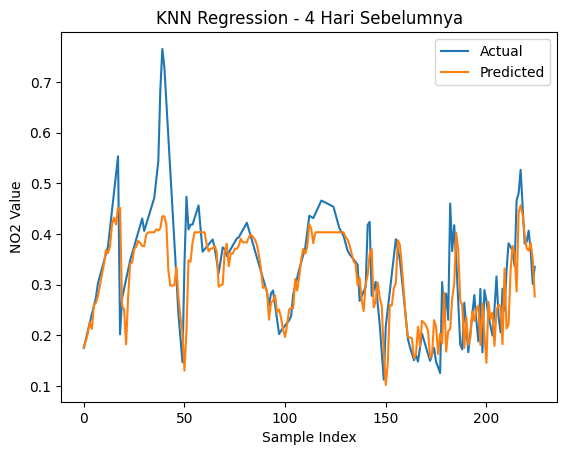

In [50]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

10 hari sebelum:

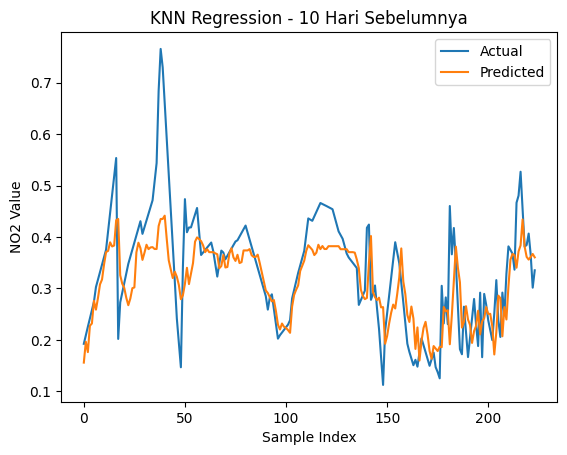

In [51]:
plt.figure()
plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")
plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

30 hari sebelum:

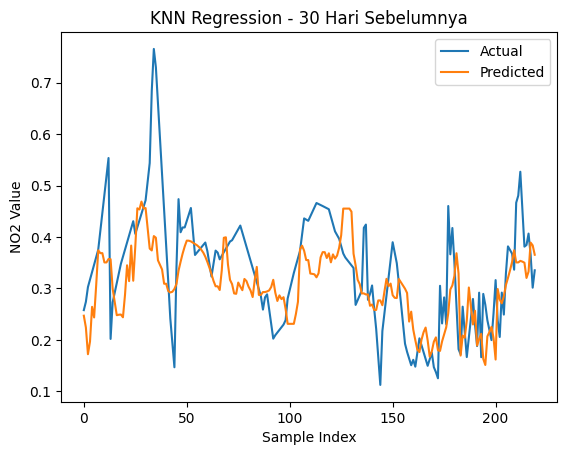

In [52]:
plt.figure()
plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")
plt.title("KNN Regression - 30 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

### f. Prediksi NO2 Hari Besok
Menggunakan model KNN yang sudah di-train, kita prediksi kadar NO2 untuk hari besok berdasarkan 2 hari terakhir data yang tersedia.

In [62]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

# 1️⃣ Baca data
df = pd.read_csv("no2_timeseries_interpolated.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2️⃣ Normalisasi
scaler = MinMaxScaler()
df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

# 3️⃣ Buat supervised dataset lag 2
def create_supervised(data, n_lag=2):
    df_sup = pd.DataFrame()
    for i in range(n_lag, 0, -1):
        df_sup[f'NO2(t-{i})'] = data.shift(i)
    df_sup['NO2(t)'] = data
    df_sup.dropna(inplace=True)
    return df_sup

supervised_df = create_supervised(df['NO2_scaled'], n_lag=2)

# 4️⃣ Train KNN dengan n_neighbors <= jumlah sample train
X = supervised_df.drop(columns=['NO2(t)']).values
y = supervised_df['NO2(t)'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

n_neighbors = min(5, len(X_train))  # pastikan tidak lebih dari train size
knn_model = KNeighborsRegressor(n_neighbors=n_neighbors)
knn_model.fit(X_train, y_train)

KNeighborsRegressor()

In [63]:
# Ambil 2 hari terakhir
last_2_days = df['NO2_scaled'].values[-2:]
last_2_dates = df['date'].values[-2:]

print("Data 2 hari terakhir yang digunakan untuk prediksi:")
for i, (d, v) in enumerate(zip(last_2_dates, last_2_days)):
    print(f"  t-{2-i}: {pd.Timestamp(d).strftime('%Y-%m-%d')} -> NO2 scaled: {v:.6f}")

# Prediksi
input_data = last_2_days.reshape(1, -1)
pred_scaled = knn_model.predict(input_data)[0]

# Inverse transform ke nilai asli
pred_original = scaler.inverse_transform([[pred_scaled]])[0][0]

# Tanggal besok
tomorrow = pd.Timestamp(df['date'].values[-1]) + pd.Timedelta(days=1)

print(f"\n========================================")
print(f"  PREDIKSI NO2 SAMPANG")
print(f"  Tanggal: {tomorrow.strftime('%Y-%m-%d')}")
print(f"  Kadar NO2 (scaled): {pred_scaled:.6f}")
print(f"  Kadar NO2 (asli)  : {pred_original:.10f}")
print(f"========================================")

Data 2 hari terakhir yang digunakan untuk prediksi:
  t-2: 2026-05-30 -> NO2 scaled: 0.301584
  t-1: 2026-05-31 -> NO2 scaled: 0.335312

  PREDIKSI NO2 SAMPANG
  Tanggal: 2026-06-01
  Kadar NO2 (scaled): 0.321062
  Kadar NO2 (asli)  : 0.0000209071
